So we have a pretty good model but now we want to perturb it a bit to see if we can do better ie get a better model in terms of out of sample rmse.

In [33]:
library(IRdisplay)

# Packages are now installed via conda, just load them
library(smooth)
library(forecast)

fdf <- read.csv("data/fluview_clean/ilinet_final.csv")
y <- as.numeric(fdf$age_0_4)


# stopifnot(h < n)

source("transformations.R")
# we need this to transform the data back so that we can make sure we are actually beating the rmse
# note doing everything on log scale runs the risk of underweighting fa

out_of_sample_rmse <- function(data,orders,sse_to_beat = Inf) {
    h <- 104
    n <- length(data)
    test_idx <- (n - h + 1):n
    sse <- 0
    previous_fit <- NULL
    fc <- numeric(length=h)
    for (i in seq_along(test_idx)) {
        t_idx <- test_idx[i]
        train_i <- data[1:(t_idx - 1)]
        fit_i <- msarima(
            train_i,
            model = previous_fit,
            orders = orders,
            lags = c(1, 52, 19),
        )
        previous_fit <- fit_i
        fc_i <- forecast(fit_i, h = 1)
        fc[i] <- fc_i$mean[1]
        sse <- sse + (expm1(data[t_idx])-expm1(fc_i$mean[1]))^2
        if (sse > sse_to_beat) {
            return (list(rmse = Inf, forecasts = numeric(length=h),fit = fit_i))
        }
    }
    return (list(rmse = sqrt(sse/h), forecasts = expm1(fc), close_fit = previous_fit))
}

results <- out_of_sample_rmse(y, orders = list(ar=c(1,0,1), i=c(1,1,0), ma=c(1,0,1)))
# plot(results$forecasts, type='l')
# plot(holdout, type='l')


In [6]:
# Now we want a function to vary the orders to see if we can do any better!!

perturb_orders <- function(orders, perturbation) {
    perturbed_orders <- lapply(orders, function(order) {
        order <- as.integer(order)
        order + sample(seq(-perturbation, perturbation), length(order), replace = TRUE)
    })
    perturbed_orders <- lapply(perturbed_orders, function(order) pmax(order, 0))
    names(perturbed_orders) <- names(orders)
    return(perturbed_orders)
}

In [34]:
# so now we can perturb and look for the best rmse
order_string <- function(orders) {
    paste0(
        "ar=c(", paste(orders$ar, collapse = ", "), ")",
        ", i=c(", paste(orders$i, collapse = ", "), ")",
        ", ma=c(", paste(orders$ma, collapse = ", "), ")"
    )
}

find_best_rmse_out_of_sample <- function(data, initial_orders, perturbation, iterations) {
    results <- out_of_sample_rmse(data, orders = initial_orders)
    best_rmse <- results$rmse
    best_fc <- results$forecasts
    current_orders <- initial_orders
    fit <- results$close_fit
    best_sse <- best_rmse^2 * 104  # Convert RMSE back to SSE for comparison
    for (i in 1:iterations) {
        # for each itteration we want to perturb if the to try and improve the rmse on the out of sample data.
        # we optimise our search such that when we are calculating the sse along the one step rolling forecast, 
        # if we exceed the best sse so far then we must have a worse rmse and we can stop! This speeds up our search as
        # refitting the model is expensive part of the search process.
        clear_output(wait = TRUE)
        new_orders <- perturb_orders(current_orders, perturbation)
        results <- out_of_sample_rmse(data, orders = new_orders,sse_to_beat = best_sse)
        # display_text(paste("Processing iteration:", i))
        
        if (results$rmse < best_rmse) {
            best_fc <-results$forecasts
            best_rmse <- results$rmse
            fit <- results$close_fit
            best_sse <- best_rmse^2 * 104  # Update the best SSE for the next comparison
            current_orders <- new_orders
        }
        
        display_text(paste("Complete: ",round(i/iterations*100) ,"%", "Best Orders:", order_string(current_orders), "Best RMSE so far:", best_rmse, "\n"))
    }
    return(list(best_orders = current_orders, best_rmse = best_rmse,best_fc=best_fc, fit=fit))
}

## VARMA and msts

In [14]:
# VARMA model for non_ilitotal, num_of_providers, and ili_total
# Taking into account differencing and seasonal lags at 19 and 52

# Load required packages
library(MTS)  # For VARMA models
library(urca)  # For cointegration tests
library(tseries)  # For stationarity tests
library(forecast)  # For auto.arima

# Prepare the multivariate data
vars_data <- fdf[, c("non_ilitotal", "num_of_providers", "ili_total")]
vars_data <- na.omit(vars_data)  # Remove any NA values

# Check for stationarity and apply differencing if needed
adf_tests <- lapply(vars_data, function(x) adf.test(x)$p.value)
print("ADF test p-values (stationarity):")
print(adf_tests)

# Apply seasonal differencing at lag 52 (weekly seasonality)
vars_seasonal_diff <- apply(vars_data, 2, function(x) diff(x, lag = 52))
vars_seasonal_diff <- as.data.frame(vars_seasonal_diff)

# Check stationarity after seasonal differencing
adf_tests_seasonal <- lapply(vars_seasonal_diff, function(x) adf.test(x)$p.value)
print("ADF test p-values after seasonal differencing (lag 52):")
print(adf_tests_seasonal)

# If still not stationary, apply first differencing
if(any(unlist(adf_tests_seasonal) > 0.05)) {
  vars_diff <- apply(vars_seasonal_diff, 2, diff)
  vars_diff <- as.data.frame(vars_diff)
  print("Applied additional first differencing")
} else {
  vars_diff <- vars_seasonal_diff
}

# Final stationarity check
adf_tests_final <- lapply(vars_diff, function(x) adf.test(x)$p.value)
print("Final ADF test p-values:")
print(adf_tests_final)

# Cross-correlation analysis to identify lags
print("Cross-correlations at lag 19:")
ccf(vars_diff$non_ilitotal, vars_diff$num_of_providers, lag.max = 19, main = "non_ilitotal vs num_of_providers")
ccf(vars_diff$non_ilitotal, vars_diff$ili_total, lag.max = 19, main = "non_ilitotal vs ili_total")
ccf(vars_diff$num_of_providers, vars_diff$ili_total, lag.max = 19, main = "num_of_providers vs ili_total")

# Check for cointegration
coint_test <- ca.jo(vars_data, type = "trace", K = 2)
print("Johansen cointegration test:")
print(summary(coint_test))

# Fit VAR model (simpler than VARMA for initial analysis)
var_model <- vars::VAR(vars_diff, p = 1, type = "const")
print("VAR model summary:")
print(summary(var_model))

# Alternatively, fit separate SARIMA models with exogenous variables
# This accounts for the relationships between variables
xreg_matrix <- as.matrix(vars_data[, c("num_of_providers", "ili_total")])

sarima_non_ili <- auto.arima(vars_data$non_ilitotal,
                            xreg = xreg_matrix,
                            seasonal = TRUE,
                            stepwise = FALSE,
                            approximation = FALSE)

xreg_matrix_providers <- as.matrix(vars_data[, c("non_ilitotal", "ili_total")])
sarima_providers <- auto.arima(vars_data$num_of_providers,
                              xreg = xreg_matrix_providers,
                              seasonal = TRUE,
                              stepwise = FALSE,
                              approximation = FALSE)

xreg_matrix_ili <- as.matrix(vars_data[, c("non_ilitotal", "num_of_providers")])
sarima_ili <- auto.arima(vars_data$ili_total,
                        xreg = xreg_matrix_ili,
                        seasonal = TRUE,
                        stepwise = FALSE,
                        approximation = FALSE)

print("SARIMA with exogenous variables - non_ilitotal:")
print(sarima_non_ili)

print("SARIMA with exogenous variables - num_of_providers:")
print(sarima_providers)

print("SARIMA with exogenous variables - ili_total:")
print(sarima_ili)

ERROR: Error in `[.data.frame`(fdf, , c("non_ilitotal", "num_of_providers", "ili_total")): undefined columns selected


In [ ]:
# write a model selection function that perturbs each one of the variables to try and better predict them...
# specifically, age_0_4	age_5_24	age_25_64	age_65. Then save each converged output to a txt file and an object so it is useable later in the analysis. 
head(fdf)

# Modelling with arima

## Single variable prediction for ilitotal
Specifically we are just using the ilitotals previous values to predict it.

In [78]:
source("./df.R")
source("./print.R")
df <- read.csv("data/fluview_clean/ilinet_final.csv")

ilitotal_model <- find_best_rmse_out_of_sample(
  df$ilitotal,
  initial_orders = list(ar=c(2, 3, 2), i=c(0, 1, 0), ma=c(3, 1, 2)),
  perturbation = 2,
  iterations = 1
)
ilitotal_holdout <- split_data(df$ilitotal)$holdout
rmse <- sqrt(mean((ilitotal_holdout - ilitotal_model$best_fc)^2))
print_rmse(rmse, "ilitotal", c("ili_total"))
ilitotal_fc <- ilitotal_model$best_fc

Complete:  100 % Best Orders: ar=c(2, 3, 2), i=c(0, 1, 0), ma=c(3, 1, 2) Best RMSE so far: 8997.34358513501 


[1] "RMSE: 88255.2196502542 for variable: ilitotal with predictors: ili_total"


### Computation to generalise calling find find_best_rmse_out_of_sample for any variable in df

In [45]:

plotresidues <- function(residuals, name) {
  par(mfrow=c(2,2))
  plot(residuals, type='l',main=paste("Residuals of", name), ylab="Residuals", xlab="Time")
  qqnorm(residuals, main=paste("QQ Plot of Residuals for", name))
  acf(residuals, main=paste("ACF of Residuals for", name),lag.max = 52)
  pacf(residuals, main=paste("PACF of Residuals for", name),lag.max = 52)
}
get_it <- function(name,initial_orders = list(ar = c(2, 1, 0), i = c(0, 1, 0), ma = c(1, 0, 0)), perturbation = 1, iterations = 50) {
  df <- read.csv("data/fluview_clean/ilinet_final.csv")
  fc <- find_best_rmse_out_of_sample(
    df[[name]],
    initial_orders = initial_orders,
    perturbation = perturbation,
    iterations = iterations
  )
  par(mfrow=c(2,2))
  residuals <-expm1(split_data(df[[name]])$holdout)-fc$best_fc
  plotresidues(residuals, name)
  return(fc)
}

## Computing the different age groups
Note we write these as seperate cells so that we can avoid rerunning all of them if we only need to fix one estimation.

Complete:  100 % Best Orders: ar=c(5, 2, 0), i=c(1, 0, 0), ma=c(4, 2, 0) Best RMSE so far: 1890.60777465033 


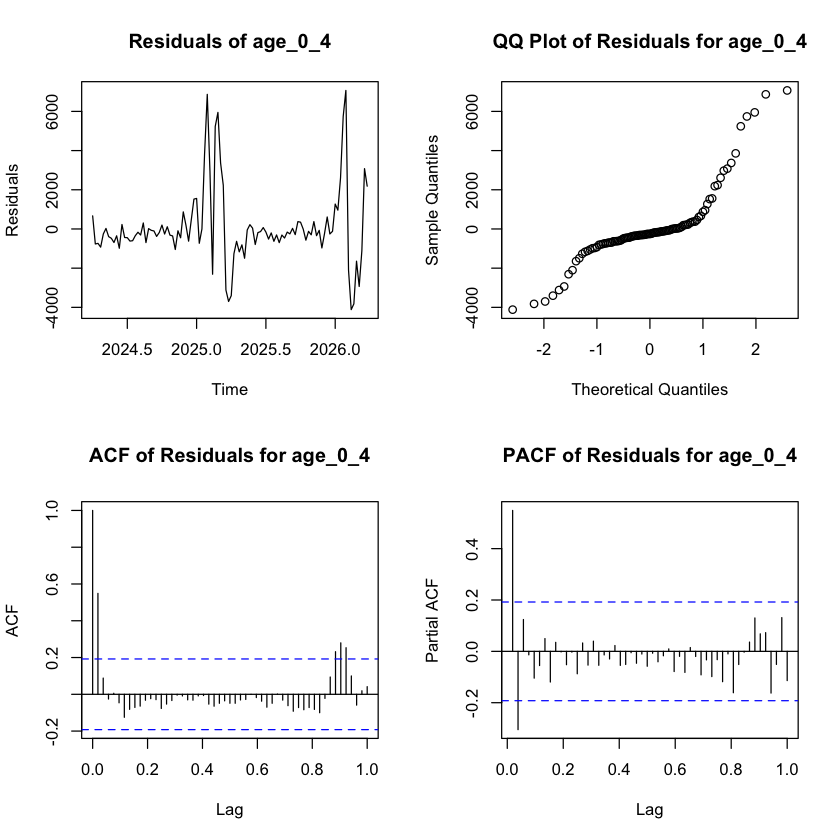

In [36]:
initial_orders_age_0_4 = list(ar=c(5, 2, 0), i=c(1, 0, 0), ma=c(4, 2, 0))

fc_age_0_4 <- get_it("age_0_4", initial_orders = initial_orders_age_0_4, perturbation = 2,iterations = 1)
fc_age_0_4_fc <- fc_age_0_4$best_fc
fc_age_0_4_fit <-fc_age_0_4$fit

In [ ]:
initial_orders_age_5_24 = list(ar=c(2, 1, 2), i=c(0, 1, 0), ma=c(2, 0, 1))
fc_age_5_24 <- get_it("age_5_24", initial_orders = initial_orders_age_5_24, perturbation = 4)
# we use this so if it is taking to long we can stop the output and still have our forecast!
fc_age_5_24_values <- fc_age_5_24$best_fc
fc_age_5_24_fit <- fc_age_5_24$fit

Complete:  100 % Best Orders: ar=c(1, 2, 1), i=c(0, 0, 1), ma=c(1, 1, 0) Best RMSE so far: 3966.20247258352 


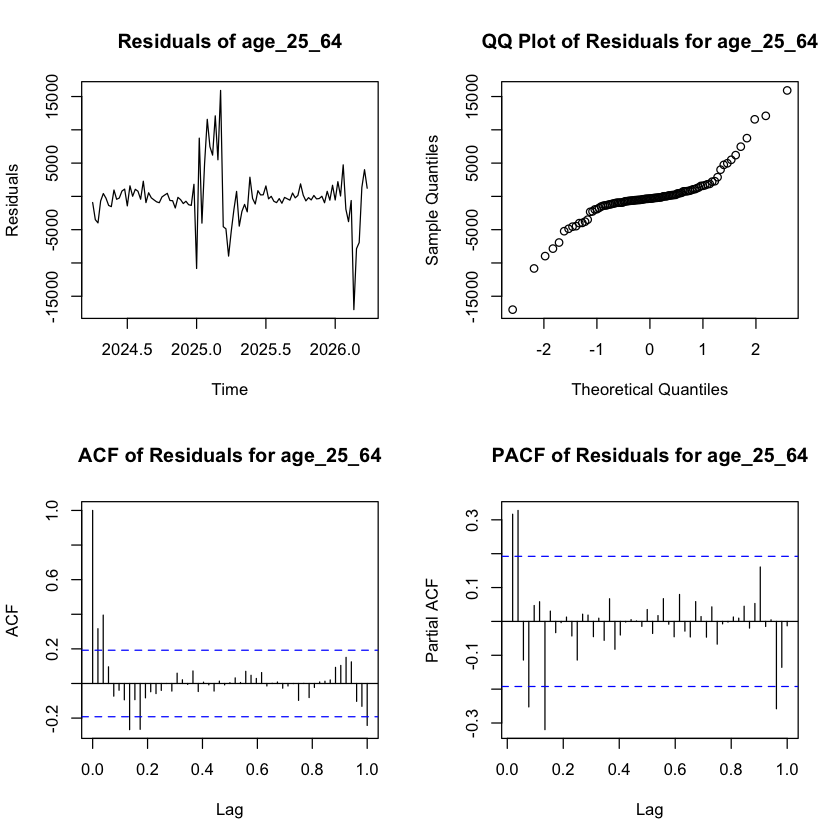

In [ ]:
initial_orders_age_25_64 = list(ar=c(1, 2, 1), i=c(0, 0, 1), ma=c(1, 1, 0))
fc_age_25_64 <- get_it("age_25_64", initial_orders = initial_orders_age_25_64,perturbation = 2)
# we use this so if it is taking to long we can stop the output and still have our forecast!
fc_age_25_64_values <- fc_age_25_64$best_fc
fc_age_25_64_fit <- fc_age_25_64$fit

In [43]:
initial_orders_age_65 = list(ar=c(1, 1, 0), i=c(0, 1, 0), ma=c(0, 1, 1))
fc_age_65 <- get_it("age_65", initial_orders = initial_orders_age_65,perturbation = 2, iterations = 50)
fc_age_65_values <- fc_age_65$best_fc
fc_age_65_fit <- fc_age_65$fit

Complete:  60 % Best Orders: ar=c(1, 1, 0), i=c(0, 1, 0), ma=c(0, 1, 1) Best RMSE so far: 1515.54718072021 


[1] "RMSE: 86799.6645660174 for variable: ilitotal with predictors: age_0_4, age_5_24, age_25_64, age_65"


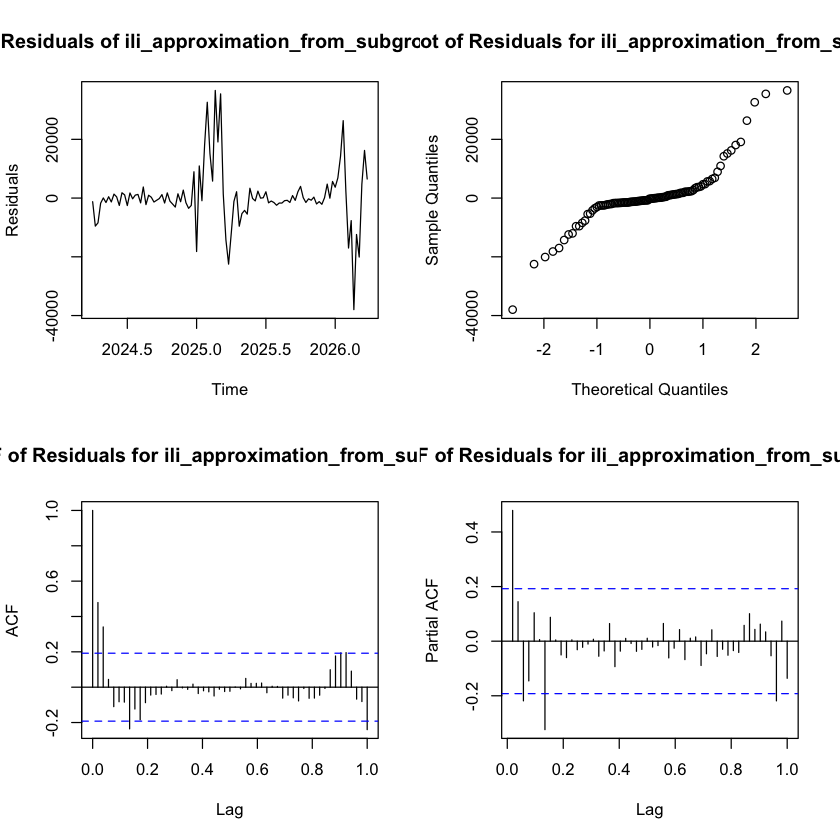

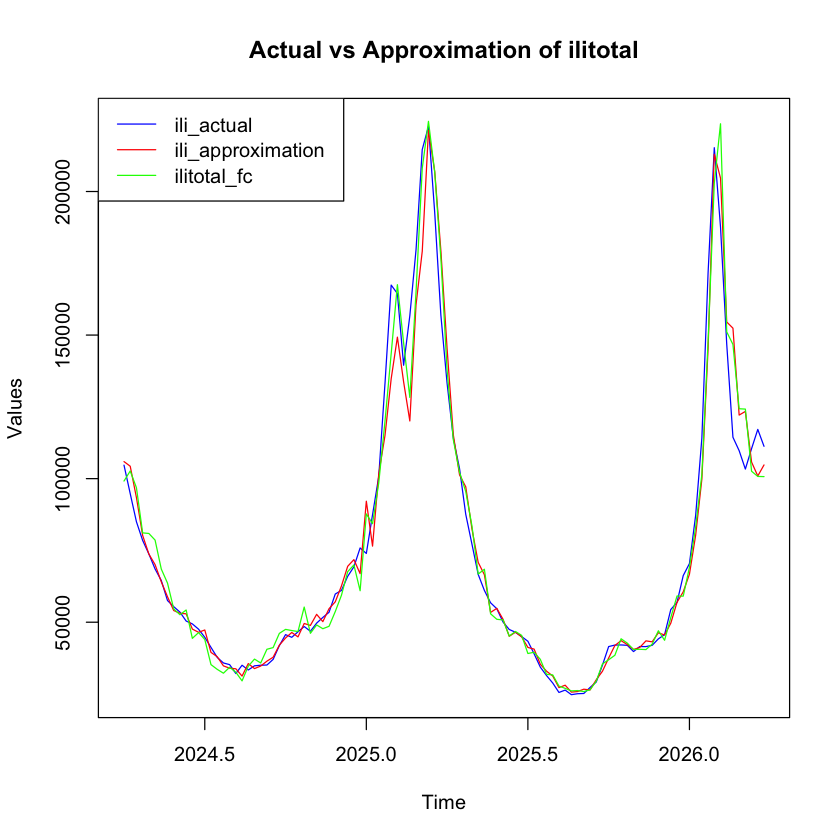

In [79]:
ili_approximation_from_subgroups <- fc_age_0_4$best_fc+fc_age_5_24$best_fc+fc_age_25_64$best_fc+fc_age_65$best_fc
ilitotal_holdout <- split_data(df$ilitotal)$holdout

print_rmse(sqrt(mean((ilitotal_holdout - ili_approximation_from_subgroups)^2)), "ilitotal", c("age_0_4", "age_5_24", "age_25_64", "age_65"))
plotresidues(expm1(ilitotal_holdout)-ili_approximation_from_subgroups, "ili_approximation_from_subgroups")
# plot(ilitotal_holdout*0+ili_approximation_from_subgroups,type='l', main="Approximation of ilitotal from subgroups", ylab="Approximation", xlab="Time")
# plot(expm1(ilitotal_holdout))
par(mfrow = c(1, 1))
ts.plot(expm1(ilitotal_holdout), ili_approximation_from_subgroups,ilitotal_fc, col=c("blue", "red","green"), main="Actual vs Approximation of ilitotal", ylab="Values", xlab="Time")
legend("topleft", 
       legend = c("ili_actual", "ili_approximation", "ilitotal_fc"), 
       col = c("blue", "red", "green"), 
       lty = c(1, 1, 1))

In [76]:

print(rmse_joint)
print(rmse)
df <- read.csv("data/fluview_clean/ilinet_final.csv")

values <- split_data(df$ilitotal)
plot(values$holdout, type='l')
rmse <- sqrt(mean((values$holdout - (exp(ilitotal_fc$best_fc)-1))^2))
rmse_joint <- sqrt(mean((values$holdout - (ili_sus))^2))
plot(values$holdout-ilitotal_fc$best_fc), type='l')
plot(values$holdout-ili_sus,type = "l")
# plot(, type='l')

ERROR: Error in parse(text = input): <text>:10:41: unexpected ','
9: rmse_joint <- sqrt(mean((values$holdout - (ili_sus))^2))
10: plot(values$holdout-ilitotal_fc$best_fc),
                                            ^


In [ ]:


# v <- arima(values$train, order = c(1, 1, 1),seasonal = list(order = c(1, 1, 0), period = 52))
# acf(fc_non_ilitotal)

## FC non_ilitotal

This is about trying to see if we can minimise non_ilitotal.

In [ ]:
fc_non_ilitotal <- get_it("non_ilitotal")

# Unweighted ILI_percentage

In [ ]:
fc_non_ilitotal_exp <- exp(fc_non_ilitotal$best_fc)-1
fc_total_patients <- ili_sus +fc_non_ilitotal_exp
total_patients <- df$ilitotal+exp(df$non_ilitotal)-1
total_patients_holdout <- split_data(total_patients)$holdout
rmse_total <- sqrt(mean((total_patients_holdout - fc_total_patients)^2))
print(paste("Total patients forecast RMSE:", rmse_total))
plot(total_patients_holdout - fc_total_patients)
# percentage_ratio <- ili
percentage_ratio_unweighted_estimate <- numeric(length = length(fc_total_patients))
if(any(fc_total_patients==0)){
    percentage_ratio_unweighted_estimate <- 0
} else {
    percentage_ratio_unweighted_estimate <- (ili_sus) / fc_total_patients*100
}

actual_unweighted_percentage_ratio <- split_data(df$percent_unweighted_ili)
plot(actual_unweighted_percentage_ratio$holdout-percentage_ratio_unweighted_estimate, type='l')

rmse_unweighted_percentage_ratio <- sqrt(mean((actual_unweighted_percentage_ratio$holdout - percentage_ratio_unweighted_estimate)^2))
print(paste("Unweighted percentage ratio RMSE:", rmse_unweighted_percentage_ratio))
